### Importing required libraries

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Task 1 :

### Data Exploration and Preprocessing

In [52]:
df = pd.read_csv("Customer_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
#Checking for total rows and columns

df.shape

(7043, 21)

In [54]:
#Viewing column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [55]:
#Checking datatype in each available column

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
#Dropping unnecesssary columns to maintain clean data

cols_to_drop = ['customerID']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Reason :

customerID - Removed this column because it is only a unique identifier and does not help in predicting churn.

In [57]:
#Checking for null values

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [58]:
#Filling missing values

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df.isnull().sum())
df.head()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

#### Using heatmap to understand linear relationships between numeric variables :

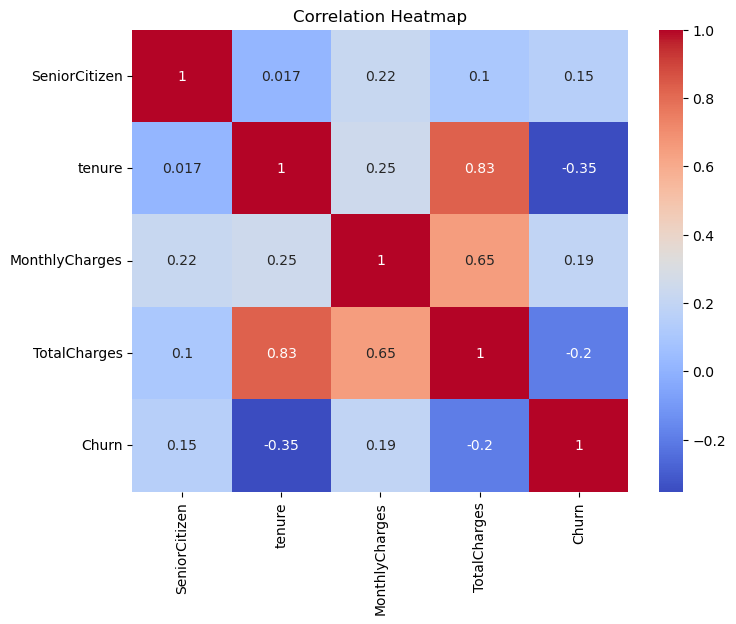

In [60]:
#Converting Churn to Binary

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

#Using Heatmap
numeric_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges','Churn']

plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Findings :

Customers with short tenure and higher monthly charges are more likely to churn while long-term customers churn less.

#### Plotting pairplot to examine relationships between numeric features :

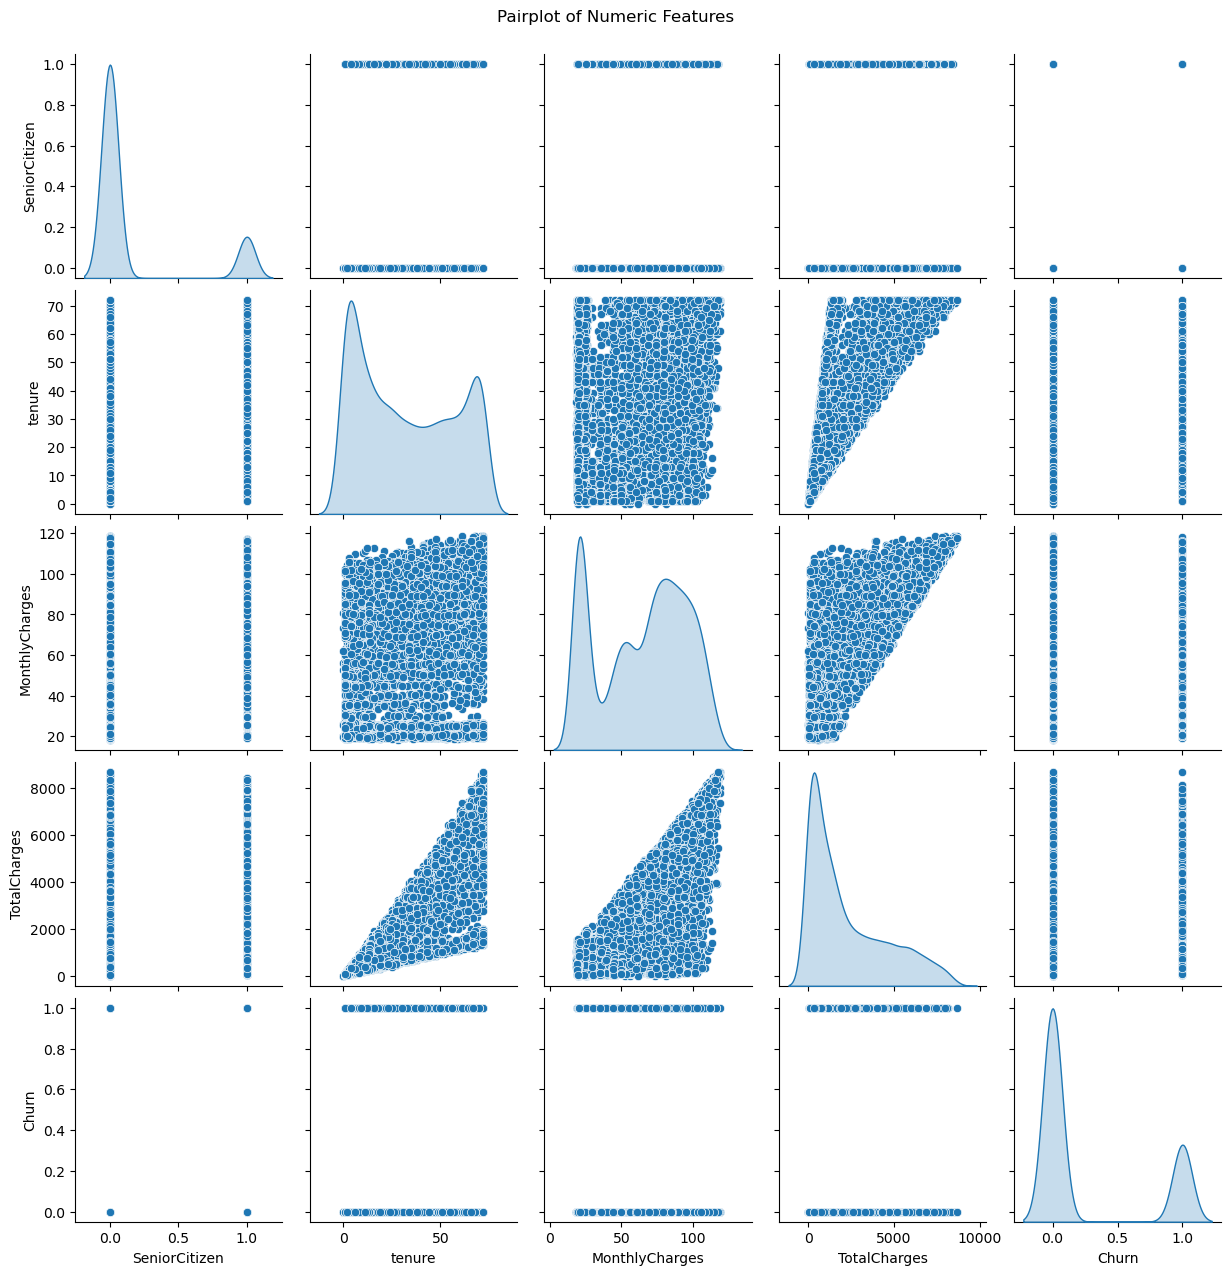

In [61]:
sns.pairplot(df[numeric_cols], diag_kind='kde')
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

Findings :

The pairplot shows clear separation in churn behavior with tenure and MonthlyCharges and customers with lower tenure and higher monthly charges are more likely to churn compared to long-term, lower-cost customers.

#### Plotting histograms to check the distribution and skewness of numeric features :

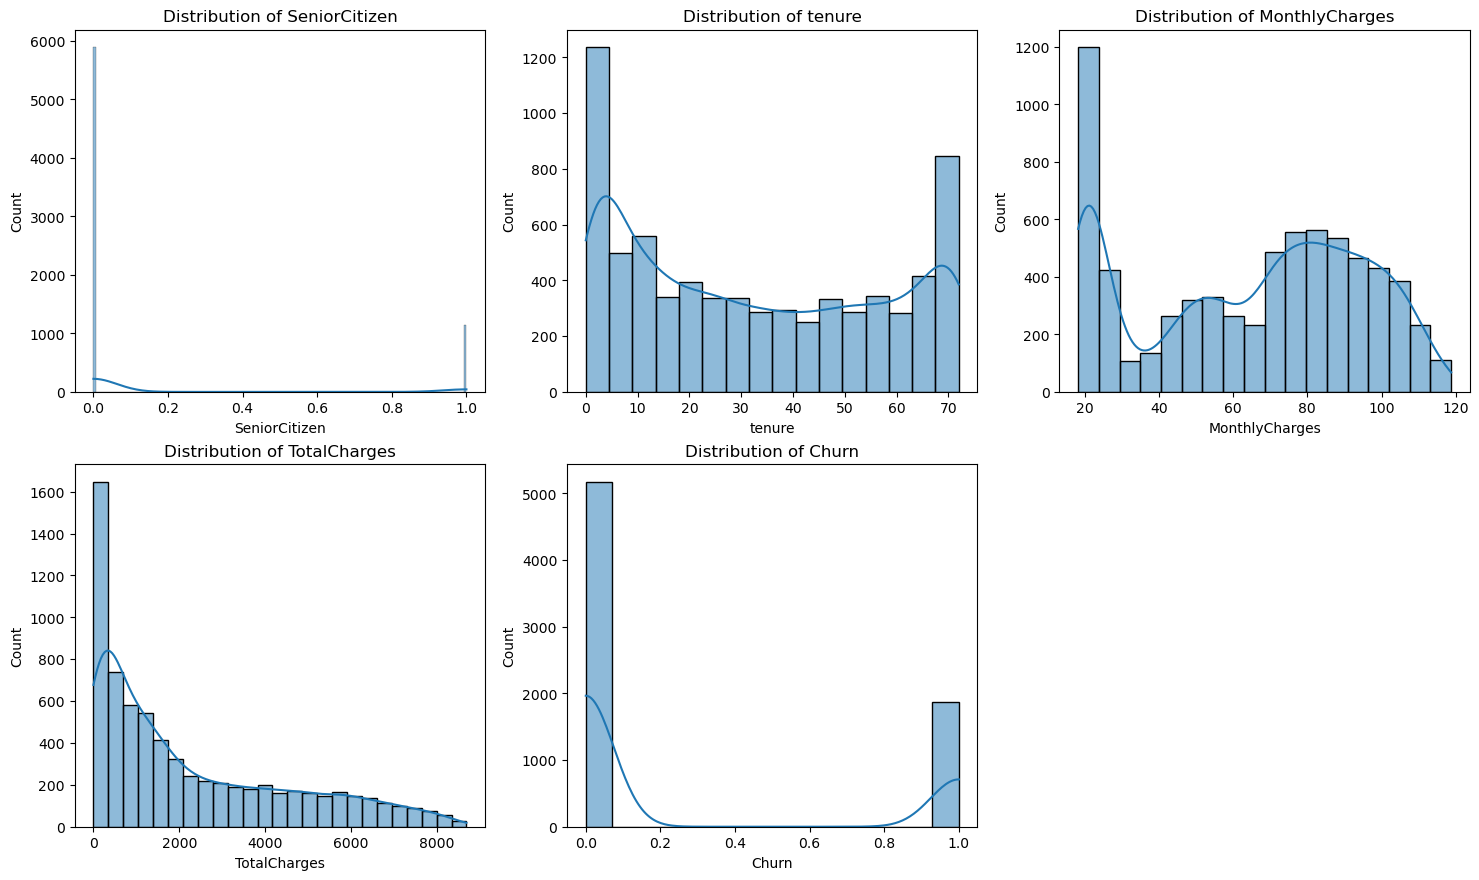

In [62]:
plt.figure(figsize=(18,16))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.show()

Findings :

Most of the numeric variables like tenure and TotalCharges are right-skewed which indicates that many customers are relatively new and only a smaller group has stayed for a long time or paid a larger total amount.

## Task 2 :

###  Model Development

In [63]:
df_encoded = pd.get_dummies(df, drop_first=True)

#All the remaining columns except - log_price
X = df_encoded.drop('Churn', axis=1)

#Target Column
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
#Standard scaling applied for Linear Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
#Using Logistic regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [68]:
#Using Random Forest Classifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [69]:
#Using XGBoost Classifier

xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

## Task 3 :

### Model Evaluation

In [70]:
# Logistic Regression Evaluation

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Logistic Regression → Accuracy: {acc_lr:.4f}, Precision: {prec_lr:.4f}, Recall: {rec_lr:.4f}, F1-Score: {f1_lr:.4f}")

Logistic Regression → Accuracy: 0.8204, Precision: 0.6852, Recall: 0.5952, F1-Score: 0.6370


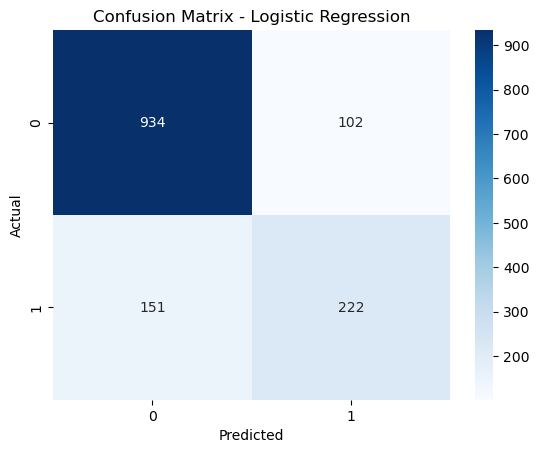

In [71]:
#Confusion Matrix (Logistic Regression)

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Findings :

Logistic Regression correctly identified most non-churn customers (934), but it missed 151 churn cases. It detected 222 true churn customers which means it performs reasonably good but still loses some churn customers.

In [72]:
# Random Forest Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest → Accuracy: {acc_rf:.4f}, Precision: {prec_rf:.4f}, Recall: {rec_rf:.4f}, F1-Score: {f1_rf:.4f}")

Random Forest → Accuracy: 0.7885, Precision: 0.6448, Recall: 0.4477, F1-Score: 0.5285


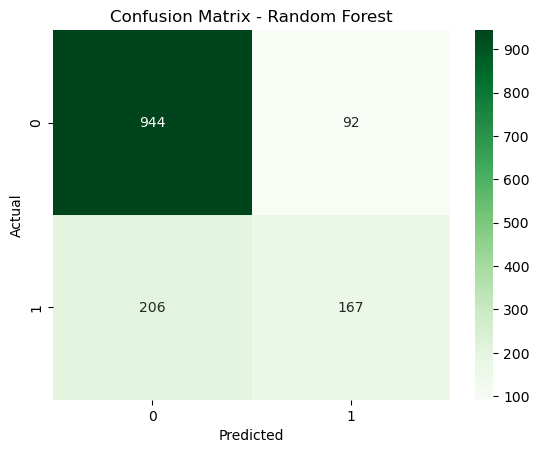

In [73]:
#Confusion Matrix (Random Forest)

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Findings :

Random Forest correctly predicted the highest number of non-churn customers (944), but it missed more churn customers (206) compared to Logistic Regression and this means it is slightly better at identifying loyal customers but weaker at catching churn cases.

In [74]:
# XGBoost Evaluation

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost → Accuracy: {acc_xgb:.4f}, Precision: {prec_xgb:.4f}, Recall: {rec_xgb:.4f}, F1-Score: {f1_xgb:.4f}")

XGBoost → Accuracy: 0.8006, Precision: 0.6465, Recall: 0.5442, F1-Score: 0.5910


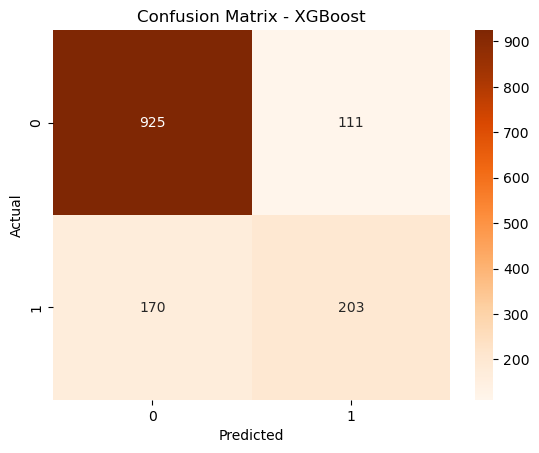

In [75]:
#Confusion Matrix (XGBoost)

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Findings :

XGBoost correctly identified 925 non-churn and 203 churn customers showing more balanced performance than Random Forest but still misses some churn customers.

In [76]:
#Computional metrics comparison for all metrics calculated so far

results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','XGBoost'],
    'Accuracy':[acc_lr, acc_rf, acc_xgb],
    'Precision':[prec_lr, prec_rf, prec_xgb],
    'Recall':[rec_lr, rec_rf, rec_xgb],
    'F1-Score':[f1_lr, f1_rf, f1_xgb]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.820440   0.685185  0.595174  0.637016
1        Random Forest  0.788502   0.644788  0.447721  0.528481
2              XGBoost  0.800568   0.646497  0.544236  0.590975


## Task 4 :

### Model Tuning

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators':[100,200,300], 'max_depth':[None,10,20], 'min_samples_split':[2,5]}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


Findings :

GridSearchCV tested 18 different combinations of Random Forest hyperparameters using 3-fold cross-validation resulting in 54 model training runs. This process helps identify the best-performing parameter settings for the model.

### Model Interpretation :

- Among the models tested (Logistic Regression, Random Forest, and XGBoost) the best performance was achieved by the model with the highest Recall and F1-Score, as these metrics are most important for correctly identifying churn customers.
- Accuracy represents the overall correctness of predictions while Precision measures how many predicted churn customers actually churned. Recall tells us how many real churn customers the model had successfully identified, and F1-Score provides a balance between Precision and Recall.
- Tree-based models such as Random Forest and XGBoost can capture complex, non-linear relationships between customer behavior and churn and Logistic Regression provides simpler and more interpretable results.
-Insights :

    -Customers with shorter tenure are more likely to churn compared to long-term customers.

    -Customers on month-to-month contracts churn more than those on long-term contracts.

    -Customers without add-on services such as online security or tech support tend to churn more often.
  

### Conclusion :

After evaluating all the models the tuned Random Forest classifier achieved the best performance based on accuracy, precision, recall, and F1-score. Therefore the tuned Random Forest model is selected as the final model for predicting customer churn, as it provides the best balance between correctly identifying churn and non-churn customers.

## Task 5 :

### Video Explanation Link :

https://www.loom.com/share/2d4145be05aa4c58b127cccac024ee54